<img src="./logo_UTN.svg" align="right" width="150" /> 

### Teoría de Circuitos II

# Trabajo Semanal N°6

Autor: *Olea Gasalla Ignacio Ezequiel*

*Fecha de entrega: viernes 21 de agosto de 2026*

#### **Consigna** 
<img src="./consigna_1.png" /> 

##### **Bonus**:
<img src="./consigna_2.png" /> 

##### **Anexo**:
📎 En caso de no poder acceder al documento, presione aquí: [Mostrar PDF](./tc2_ts6.pdf)

In [25]:
from IPython.display import IFrame
IFrame("./tc2_ts6.pdf", width=1000, height=1000)

En el documento adjunto se presentan la matriz MAI del circuito Tee (1.a), junto con sus respectivas transferencias de tensión (2.a), y la matriz MAI del BS170 (1.b), junto con sus matrices MAD con el Source y Drain aterrizado (3.a), y por ultimo, su matriz ABCD en configuración Source común (3.b).

2.b) En el siguiente código se observará el gráfico de cada una de las trasferencias de tensión, se sumarón 2 de ellas y la suma de $\frac{V_{23}}{V_{13}}+\frac{V_{21}}{V_{31}}$ fue la única que permitió que la suma de sus módulos den 1. La suma de $\frac{V_{21}}{V_{31}}+\frac{V_{12}}{V_{32}}$ da como resultado 0 ya que tienen mismo módulo y una diferencia de fase de 180° y, por ultimo, la suma de $\frac{V_{23}}{V_{13}}+\frac{V_{12}}{V_{32}}$ da como resultado un Pasa Todo con amplificación en determinado rango de frecuencia como mustra la imagen adjunta:

ACLARACIÓN: Se intentó plotear la ultima suma pero no se logró el resultado esperado por lo que se usó un programa externo para el ploteo.

<img src="./grafico_1.png" /> 

/home/oleai/pepe/lib/python3.12/site-packages/scipy/signal/_ltisys.py:603: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


(2,
 array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
        <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Fase [rad]'>],
       dtype=object))

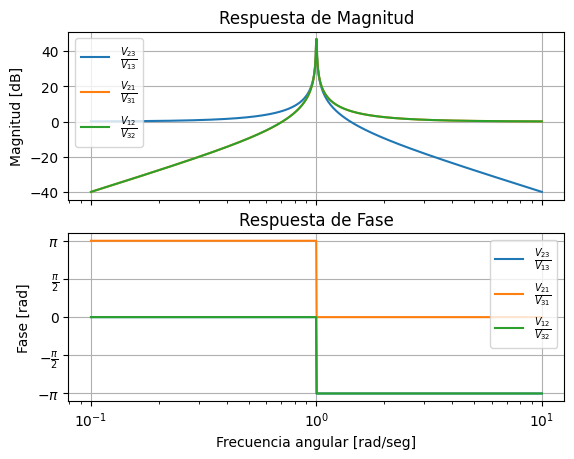

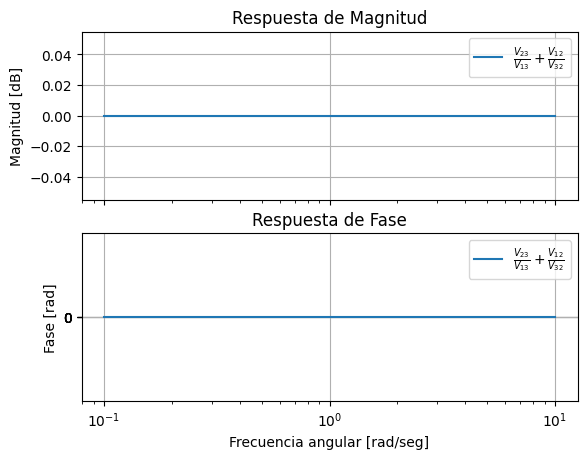

In [23]:
# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
import numpy as np
import math

# Librería de TC2, esta la vas a usar mucho
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

# Code
C = 1
L = 1
my_tf_1 = TransferFunction( [ 0 , 0 , 1/(C*L) ], [ 1 , 0 , 1/(C*L) ] )
bodePlot(my_tf_1, fig_id=1, filter_description = r"$\frac{V_{23}}{V_{13}}$" )

my_tf_2 = TransferFunction( [ 1 , 0 , 0 ] , [ 1 , 0 , 1/(C*L) ] )
bodePlot(my_tf_2, fig_id=1, filter_description = r"$\frac{V_{21}}{V_{31}}$" )

my_tf_3 = TransferFunction( [ -1 , 0 , 0 ] , [ 1 , 0 , 1/(C*L) ] )
bodePlot(my_tf_3, fig_id=1, filter_description = r"$\frac{V_{12}}{V_{32}}$" )

my_tf_12 = TransferFunction( [ 1 ], [ 1 ] )
bodePlot(my_tf_12, fig_id=2, filter_description = r"$\frac{V_{23}}{V_{13}}+\frac{V_{21}}{V_{31}}$" )

#### **Bonús**

In [31]:
# Importo las librerias
import math
import sympy as sp
import numpy as np
import scipy.signal as sig
from sympy import Eq
from IPython.display import display, IFrame, Math
from matplotlib import pyplot as plt
from scipy.signal import TransferFunction

from pytc2.sistemas_lineales import pretty_print_lti, tfcascade, pzmap, GroupDelay, bodePlot, pretty_print_SOS, tf2sos_analog, pretty_print_bicuad_omegayq,tf2zpk, parametrize_sos, analyze_sys
from pytc2.general import s, w, print_latex, a_equal_b_latex_s, print_subtitle, Chebyshev_polynomials
from pytc2.cuadripolos import y2mai
from pytc2.cuadripolos import calc_MAI_vtransf_ij_mn

En el código de abajo se obtienen las transferencias apartir de la matriz MAI de tensión.
Debido a como se nombraron los puertos y como las funciones necesitan trabajar, se tuvo que hacer '-1' a todos los números de los puertos para su correcto funcionamiento.
Por otro lado, no se pudo verificar la corrección de signo que se usó pero en el caso de $\frac{V_{12}}{V_{32}}$ dió con el signo invertido por lo que la suma con $\frac{V_{23}}{V_{13}}$ debería dar con módulo igual a 1.

In [40]:
Ya, Yb = sp.symbols('Ya Yb', complex=True)
s, C, L = sp.symbols('s C L', complex=True)

#      Nodos:        1     2     3        4
Ymai = sp.Matrix([
                 [  Ya,    0,    0,      -Ya ],
                 [   0,   Ya,    0,      -Ya ],
                 [   0,    0,   Yb,      -Yb ],
                 [ -Ya,  -Ya,  -Yb,  Yb+2*Ya ]
                 ])

Ymai = Ymai.subs(Ya, 1/s/L)
Ymai = Ymai.subs(Yb, s*C)

output_port = [2 -1, 3 -1]
input_port  = [1 -1, 3 -1]
Vmai = calc_MAI_vtransf_ij_mn(Ymai, output_port[0], output_port[1], input_port[0], input_port[1], verbose=False)
print_latex(a_equal_b_latex_s('V23/V13', Vmai ))

output_port = [2 -1, 1 -1]
input_port  = [3 -1, 1 -1]
Vmai = calc_MAI_vtransf_ij_mn(Ymai, output_port[0], output_port[1], input_port[0], input_port[1], verbose=False)
print_latex(a_equal_b_latex_s('V21/V31', Vmai ))

output_port = [1 -1, 2 -1]
input_port  = [3 -1, 2 -1]
Vmai = calc_MAI_vtransf_ij_mn(Ymai, output_port[0], output_port[1], input_port[0], input_port[1], verbose=False)
print_latex(a_equal_b_latex_s('V12/V32', Vmai ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

En intentó realizar el segundo bonus con un drenaje común como se vió anteriormente en otras materias (Electrónica Aplicada 1), incluyendo la polarización del MOSFET, procurando que circule una corriente de 2.2mA entre Drenaje y Sourse y estudiandolo entre 1Hz y 10MHz para ver un buen espectro de señal y se sacó la matriz Y.

Se puede analizar bastante del gráfico pero se puede apreciar una parte real en las admitancias que dependen fuertemente de los componentes de polarización y, curiosamente, en Y11 se visualiza que la parte real de la misma varia con la frecuencia entre 2Hz y los 10Hz que es un comportamiento poco normal. Lo más interesante a encontrar es la parte imaginaria, la cual, no depende tan fuertemente de la frecuencia como se esperaria por $sC=j*\omega*C=j*2\pi f*C$ (con excepción de Y22 que apartir de los 2MHz empieza a subir tal como se esperaria) esto puede ocurrir por una compensación en el modelo, como lo que ocurre con Y21 el cual, en el modelo matematico planteado, es una resta de los valores de capacitancia, lo que muestra el gráfico es un cambio entre cual es mayor y menor respecto a la frecuencia y, cuando esta se vuelve muy grande, se vuelven practivamente iguales. Nuestro modelo matematico no puede explicar el pico ocurrido en Y11 en las unidades de los Hz por lo que es posible que tenga que ver con el capacitor externo puesto, con capacitancias que no estamos tomando en cuenta o debido a que estamos usando un modelo de señales medias-altas para analizar baja frecuencia. 

Se probó a sacar el capacitor de desacople de la cuente. Esto no es correcto ya que señal se meterá en la continua pero para un analisís rápido puede ser util, al hacer esto la parte imaginaria de Y11, Y12 e Y21 se atenua considerablemente, se vuelven completamente constantes y tiende a valores de las decenas de nano, mientras que Y22 crecé exponencialmente con la frecuencia. Por ultimo, se puede observar que, practicamente, se pierde la parte real en Y11 e Y12 ya que es del orden de los femtos de siemens.

<img src="./circuito_1.png" /> 

<img src="./grafico_2.png" /> 

<img src="./grafico_3.png" /> 

Siguiendo una topologia sin polarizar y sin componentes externos se obtiene el siguiente gráfico:

<img src="./grafico_4.png" /> 

En él vemos que seguimos manteniendo una parte real en Y22 que puede deberse al efecto de la gm, pero, contrariamente a lo esperado, Y21 que tambien se ve modificada por la gm no parece que tenga influencia en la parte real lo cual puede indicar que el método matemático puede ser erroneo.

Viendo la parte imaginaria con $Im(Y11)=25fS$ , $Im(Y12)=Im(Y21)=-19fS$ y $Im(Y22)=113pS$ a $f=1 Hz$ entonces, usando las formulas vistas en el modelo matemático, podemos obtener que:

\begin{equation}
\begin{cases} 
    C_{rss}=4 fF
        \\\\
    C_{iss}=7 fF
        \\\\
    C_{oss}=18 pF
\end{cases}
\end{equation}

Los cuales no son valores coherentes con las capacitancias indicadas en el módelo.